# Import libraries and load dataset

In [1]:
import pandas as pd               # Tabular data handling (DataFrame)                
import numpy as np                # Numerical operations on arrays / matric                
import matplotlib.pyplot as plt   # Basic plotting  
import seaborn as sns             # Statistical data visualization 
%matplotlib inline

In [2]:
dataset=pd.read_csv("scores_data.csv")
dataset.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Batch        149 non-null    object
 1   User_ID      149 non-null    object
 2      Score     149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


# Checking missing values

In [4]:
dataset.isnull().sum()

Batch          0
User_ID        0
   Score       0
dtype: int64

# Checking duplicate values

In [6]:
print("no.of duplicate rows =",dataset.duplicated().sum())

no.of duplicate rows = 0


# Remove spaces in column names

In [7]:
dataset.columns.tolist()

['Batch ', 'User_ID ', '   Score   ']

In [8]:
dataset.columns = dataset.columns.str.strip()
dataset.columns.tolist()

['Batch', 'User_ID', 'Score']

# Extract numeric score 

In [28]:
dataset["Score_Num"] = dataset["Score"].str.split("/").str[0].astype(int)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Batch      149 non-null    object
 1   User_ID    149 non-null    object
 2   Score      149 non-null    object
 3   Score_Num  149 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 4.8+ KB


In [31]:
dataset.head()

,Batch,User_ID,Score,Score_Num
0,AI_ELITE_7,uid_149,6 / 7,6
1,AI_ELITE_7,uid_148,6 / 7,6
2,AI_ELITE_7,uid_147,7 / 7,7
3,AI_ELITE_7,uid_146,7 / 7,7
4,AI_ELITE_7,uid_145,4 / 7,4


# statistical summary

In [32]:
dataset.describe()

,Score_Num
count,149.000000
mean,4.382550
std,1.592199
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [34]:
batch_summary = dataset.groupby("Batch")["Score_Num"].agg(Count="count",Mean="mean",Median="median",Min="min",Max="max",Std_Dev="std")
batch_summary

,Count,Mean,Median,Min,Max,Std_Dev
Batch,,,,,,
AI_ELITE_4,48,3.791667,4.0,0,7,1.443376
AI_ELITE_6,48,4.229167,4.0,0,7,1.640441
AI_ELITE_7,53,5.056604,5.0,2,7,1.446682


# Visualising Data using displot

<Figure size 640x480 with 0 Axes>

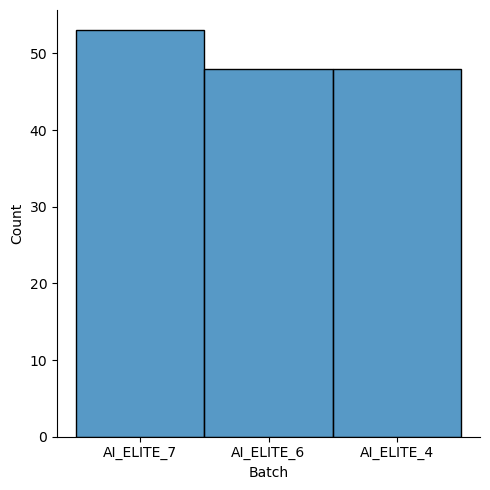

<Figure size 640x480 with 0 Axes>

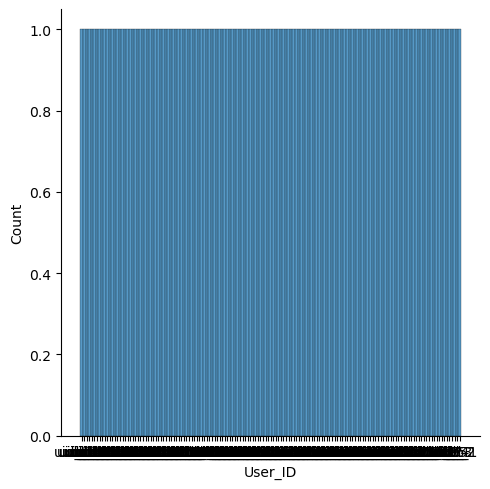

<Figure size 640x480 with 0 Axes>

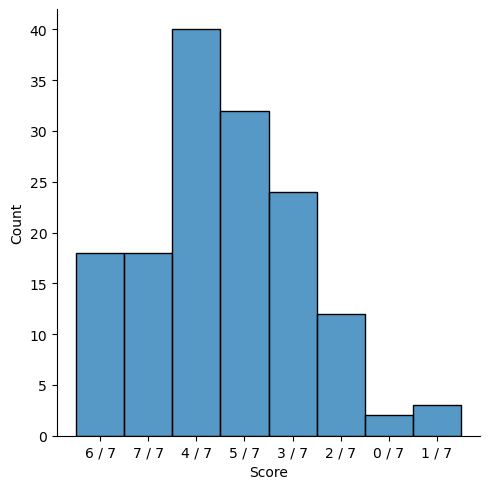

<Figure size 640x480 with 0 Axes>

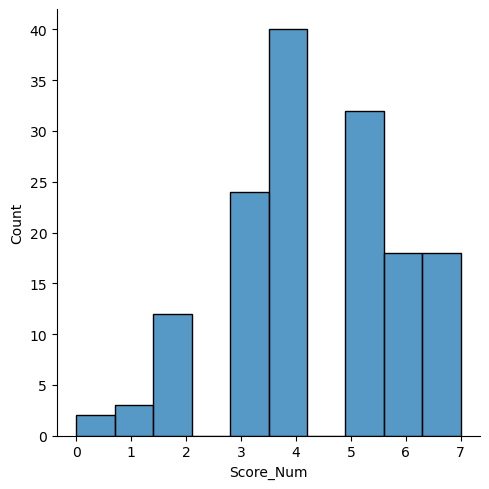

In [35]:
a=['Batch','User_ID','Score','Score_Num']
for i in a:
    plt.figure()
    sns.displot(dataset[i])
    plt.show()

# score distribution

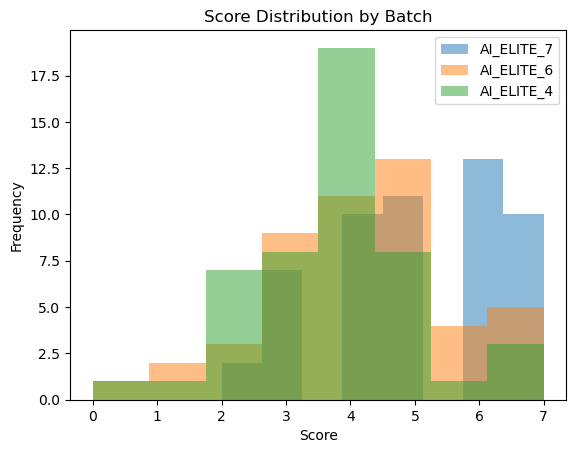

In [38]:
plt.figure()
for batch in dataset["Batch"].unique():plt.hist(dataset[dataset["Batch"] == batch]["Score_Num"],bins=8,alpha=0.5,label=batch)

plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Score Distribution by Batch")
plt.legend()
plt.show()

# Comparison using boxplot

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

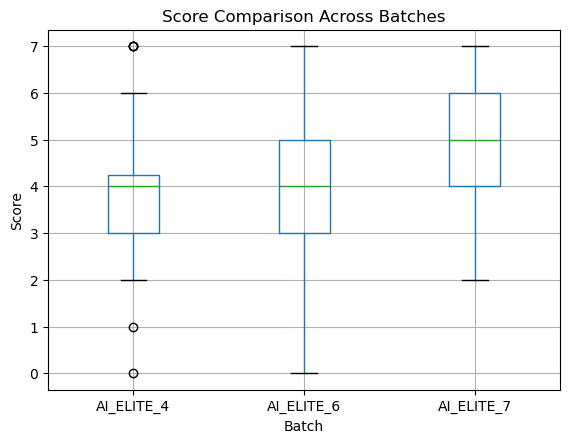

In [40]:
plt.figure()
dataset.boxplot(column="Score_Num", by="Batch")
plt.xlabel("Batch")
plt.ylabel("Score")
plt.title("Score Comparison Across Batches")
plt.suptitle("")  
plt.show()

In [42]:
best_batch = batch_summary["Mean"].idxmax()
worst_batch = batch_summary["Mean"].idxmin()

print("Insights")
print(f"Best performing batch (highest mean score): {best_batch}")
print(f"Lowest performing batch (lowest mean score): {worst_batch}")

Insights
Best performing batch (highest mean score): AI_ELITE_7
Lowest performing batch (lowest mean score): AI_ELITE_4
